# Step 1: Load + Inspect Data

In [1]:
!pip install statsforecast mlforecast neuralforecast lightgbm chronos-forecasting

In [ ]:
!pip install mlforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.8 MB/s eta 0:00:00


## Step 2 - Imports

In [2]:
import os
import numpy as np
import pandas as pd
import torch

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS, AutoARIMA

from mlforecast import MLForecast
from lightgbm import LGBMRegressor

from neuralforecast import NeuralForecast
from neuralforecast.auto import AutoNBEATS, AutoNHITS

from chronos import ChronosPipeline

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape, bias
from utilsforecast.plotting import plot_series

## Step 3: Load the hotel data

In [3]:
df = pd.read_parquet("sample_hotels-1.parquet")

df = (
    df
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)

df.head()

,unique_id,ds,holiday_flag,target_day,target_month,target_year,location_type,hotel_type,y,otb_1,...,otb_51,otb_52,otb_53,otb_54,otb_55,otb_56,otb_57,otb_58,otb_59,otb_60
0,hotel_0,2022-01-01,no,Sat,Jan,2022,NonSuburban,Resorts & Destinations,0.975309,0.679012,...,0.197531,0.197531,0.197531,0.185185,0.160494,0.160494,0.160494,0.160494,0.160494,0.160494
1,hotel_0,2022-01-02,no,Sun,Jan,2022,NonSuburban,Resorts & Destinations,0.493827,0.308642,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.061728,0.061728,0.049383
2,hotel_0,2022-01-03,no,Mon,Jan,2022,NonSuburban,Resorts & Destinations,0.456790,0.358025,...,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691
3,hotel_0,2022-01-04,no,Tue,Jan,2022,NonSuburban,Resorts & Destinations,0.592593,0.419753,...,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.037037,0.037037,0.024691,0.024691
4,hotel_0,2022-01-05,no,Wed,Jan,2022,NonSuburban,Resorts & Destinations,0.530864,0.407407,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.049383,0.049383,0.024691,0.024691,0.012346


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10172 entries, 0 to 10171
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   unique_id      10172 non-null  object        
 1   ds             10172 non-null  datetime64[us]
 2   holiday_flag   10172 non-null  object        
 3   target_day     10172 non-null  object        
 4   target_month   10172 non-null  object        
 5   target_year    10172 non-null  int32         
 6   location_type  10172 non-null  object        
 7   hotel_type     10172 non-null  object        
 8   y              10172 non-null  float64       
 9   otb_1          10172 non-null  float64       
 10  otb_2          10172 non-null  float64       
 11  otb_3          10172 non-null  float64       
 12  otb_4          10172 non-null  float64       
 13  otb_5          10172 non-null  float64       
 14  otb_6          10172 non-null  float64       
 15  otb_7          1017

## Step 4: Create output folders

In [4]:
os.makedirs("outputs", exist_ok=True)
os.makedirs("plots", exist_ok=True)

## Step 5: Create train/test split

We are forecasting the last 28 days for each hotel.

In [5]:
train = (
    df
    .groupby("unique_id", group_keys=False)
    .apply(lambda x: x.iloc[:-28])
    .reset_index(drop=True)
)

test = (
    df
    .groupby("unique_id", group_keys=False)
    .apply(lambda x: x.iloc[-28:])
    .reset_index(drop=True)
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (9640, 69)
Test shape: (532, 69)


/tmp/ipykernel_76364/2160362775.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.iloc[:-28])
/tmp/ipykernel_76364/2160362775.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.iloc[-28:])


## Step 6: Prepare StatsForecast data

In [6]:
from utilsforecast.preprocessing import fill_gaps

sf_train = train[["unique_id", "ds", "y"]]
sf_train = fill_gaps(sf_train, freq="D")
sf_train["y"] = sf_train.groupby("unique_id")["y"].ffill().bfill()
sf_train["ds"] = pd.to_datetime(sf_train["ds"])

sf_test = test[["unique_id", "ds", "y"]].copy()
sf_test["ds"] = pd.to_datetime(sf_test["ds"])

sf_train.head()

,unique_id,ds,y
0,hotel_0,2022-01-01,0.975309
1,hotel_0,2022-01-02,0.493827
2,hotel_0,2022-01-03,0.456790
3,hotel_0,2022-01-04,0.592593
4,hotel_0,2022-01-05,0.530864


## Step 7: Define StatsForecast models

In [7]:
ml_train = sf_train[["unique_id", "ds", "y"]].copy()
ml_train["ds"] = pd.to_datetime(ml_train["ds"])

ml_train = (
    ml_train
    .groupby(["unique_id", "ds"], as_index=False)["y"]
    .mean()
)

def complete_daily_series(group):
    hotel_id = group["unique_id"].iloc[0]
    full_dates = pd.date_range(
        start=group["ds"].min(),
        end=group["ds"].max(),
        freq="D"
    )
    group = (
        group
        .set_index("ds")
        .reindex(full_dates)
        .rename_axis("ds")
        .reset_index()
    )
    group["unique_id"] = hotel_id
    group["y"] = group["y"].ffill().bfill()
    return group

ml_train = (
    ml_train
    .groupby("unique_id", group_keys=False)
    .apply(complete_daily_series)
    .reset_index(drop=True)
)

print("ML train shape:", ml_train.shape)

ML train shape: (9842, 3)


/tmp/ipykernel_76364/3164633827.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(complete_daily_series)


## Step 8 Define StatsForecast models

In [8]:
sf_models = [
    Naive(),
    SeasonalNaive(season_length=7),
    AutoETS(season_length=7),
    AutoARIMA(season_length=7)
]

sf = StatsForecast(
    models=sf_models,
    freq="D",
    n_jobs=-1
)

## Step 9: Run 5-fold cross-validation

This may take a while because of AutoARIMA.

In [9]:
cv_sf = sf.cross_validation(
    df=sf_train,
    h=28,
    n_windows=5,
    step_size=28
)

cv_sf.head()

,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,hotel_0,2023-01-14,2023-01-13,0.938272,0.790123,0.629630,0.761871,0.732111
1,hotel_0,2023-01-15,2023-01-13,0.604938,0.790123,0.358025,0.561969,0.481735
2,hotel_0,2023-01-16,2023-01-13,0.469136,0.790123,0.555556,0.568555,0.502310
3,hotel_0,2023-01-17,2023-01-13,0.567901,0.790123,0.432099,0.583771,0.491153
4,hotel_0,2023-01-18,2023-01-13,0.666667,0.790123,0.456790,0.573340,0.494599


In [13]:
cv_sf.to_csv("outputs/cv_results_statsforecast.csv", index=False)

## Step 10: Evaluate StatsForecast models

In [11]:
eval_sf = evaluate(
    df=cv_sf,
    metrics=[bias, mae, rmse, mape]
)

eval_sf.head()

,unique_id,cutoff,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,hotel_0,2023-01-13,bias,0.003086,-0.256173,-0.158943,-0.247447
1,hotel_105,2023-01-13,bias,0.388814,0.004268,0.137769,0.118767
2,hotel_112,2023-01-13,bias,-0.302009,-0.102902,-0.164537,-0.145869
3,hotel_126,2023-01-13,bias,0.091633,0.018782,0.038140,0.012186
4,hotel_133,2023-01-13,bias,-0.252927,-0.156909,-0.259729,-0.154314


In [14]:
eval_sf.to_csv("outputs/evaluation_statsforecast.csv", index=False)

## Step 11: Define LightGBM model

This satisfies the ML model requirement.

In [15]:
mlf = MLForecast(
    models=[LGBMRegressor(random_state=42)],
    freq="D",
    lags=[1, 2, 3, 7, 14, 28],
    date_features=["dayofweek", "month"]
)

In [16]:
from mlforecast import MLForecast
from lightgbm import LGBMRegressor

## Step 12: LightGBM 5-fold CV

In [17]:
cv_lgb = mlf.cross_validation(
    df=ml_train,
    h=28,
    n_windows=5,
    step_size=28
)

cv_lgb.to_csv("outputs/cv_results_lightgbm.csv", index=False)
cv_lgb.head()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000199 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1550
[LightGBM] [Info] Number of data points in the train set: 6650, number of used features: 8
[LightGBM] [Info] Start training from score 0.666922
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000615 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1550
[LightGBM] [Info] Number of data points in the train set: 7182, number of used features: 8
[LightGBM] [Info] Start training from score 0.660282
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1550
[LightGBM] [Info] Number of data points in the train set: 77

,unique_id,ds,cutoff,y,LGBMRegressor
0,hotel_0,2023-01-14,2023-01-13,0.938272,0.845779
1,hotel_0,2023-01-15,2023-01-13,0.604938,0.446080
2,hotel_0,2023-01-16,2023-01-13,0.469136,0.380516
3,hotel_0,2023-01-17,2023-01-13,0.567901,0.382555
4,hotel_0,2023-01-18,2023-01-13,0.666667,0.375684


## Step 13 — Evaluate LightGBM CV

In [18]:
eval_lgb = evaluate(
    df=cv_lgb,
    metrics=[bias, mae, rmse, mape]
)

eval_lgb.to_csv("outputs/evaluation_lightgbm.csv", index=False)
eval_lgb.head()

,unique_id,cutoff,metric,LGBMRegressor
0,hotel_0,2023-01-13,bias,-0.268596
1,hotel_105,2023-01-13,bias,0.065681
2,hotel_112,2023-01-13,bias,-0.249413
3,hotel_126,2023-01-13,bias,0.065672
4,hotel_133,2023-01-13,bias,-0.184310


## Step 14: Define NBEATS and NHITS models

In [20]:
from neuralforecast.models import NBEATS, NHITS

nf_models = [
    NBEATS(h=28, input_size=56, max_steps=100),
    NHITS(h=28, input_size=56, max_steps=100)
]

nf = NeuralForecast(
    models=nf_models,
    freq="D"
)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1


## Cell 15 — NBEATS/NHITS 5-fold CV

In [21]:
# Step 13 continued — 5-fold CV
cv_nf = nf.cross_validation(
    df=sf_train,
    h=28,
    n_windows=5,
    step_size=28
)

cv_nf.to_csv("outputs/cv_results_neuralforecast.csv", index=False)
cv_nf.head()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
4.8 K     Non-trainable params
2.6 M     Total params
10.231    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,cutoff,NBEATS,NHITS,y
0,hotel_0,2023-01-14,2023-01-13,0.722356,0.760720,0.938272
1,hotel_0,2023-01-15,2023-01-13,0.425721,0.534919,0.604938
2,hotel_0,2023-01-16,2023-01-13,0.480759,0.511318,0.469136
3,hotel_0,2023-01-17,2023-01-13,0.552806,0.555264,0.567901
4,hotel_0,2023-01-18,2023-01-13,0.492388,0.561663,0.666667


## Cell 16 — Evaluate NBEATS/NHITS CV


In [22]:
eval_nf = evaluate(
    df=cv_nf,
    metrics=[bias, mae, rmse, mape]
)

eval_nf.to_csv("outputs/evaluation_neuralforecast.csv", index=False)
eval_nf.head()

,unique_id,cutoff,metric,NBEATS,NHITS
0,hotel_0,2023-01-13,bias,-0.219322,-0.176207
1,hotel_105,2023-01-13,bias,0.179358,0.180033
2,hotel_112,2023-01-13,bias,-0.140183,-0.118513
3,hotel_126,2023-01-13,bias,0.084684,0.074878
4,hotel_133,2023-01-13,bias,-0.137421,-0.160129


## Cell 17 — Combine all CV evaluations

In [23]:
eval_all = pd.concat(
    [eval_sf, eval_lgb, eval_nf],
    ignore_index=True
)

eval_all.to_csv("outputs/evaluation_all_models.csv", index=False)
eval_all.head()

,unique_id,cutoff,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA,LGBMRegressor,NBEATS,NHITS
0,hotel_0,2023-01-13,bias,0.003086,-0.256173,-0.158943,-0.247447,NaN,NaN,NaN
1,hotel_105,2023-01-13,bias,0.388814,0.004268,0.137769,0.118767,NaN,NaN,NaN
2,hotel_112,2023-01-13,bias,-0.302009,-0.102902,-0.164537,-0.145869,NaN,NaN,NaN
3,hotel_126,2023-01-13,bias,0.091633,0.018782,0.038140,0.012186,NaN,NaN,NaN
4,hotel_133,2023-01-13,bias,-0.252927,-0.156909,-0.259729,-0.154314,NaN,NaN,NaN


## Cell 18 — CV model win counts

In [24]:
model_cols = [
    c for c in eval_all.columns
    if c not in ["unique_id", "metric", "cutoff"]
]

wins = []
for _, row in eval_all.iterrows():
    wins.append({
        "unique_id":  row["unique_id"],
        "metric":     row["metric"],
        "best_model": row[model_cols].idxmin()
    })

wins_df = pd.DataFrame(wins)

win_counts = (
    wins_df
    .groupby(["metric", "best_model"])
    .size()
    .reset_index(name="wins")
    .sort_values(["metric", "wins"], ascending=[True, False])
)

win_counts.to_csv("outputs/cv_model_win_counts.csv", index=False)
display(win_counts)

/tmp/ipykernel_76364/2319252981.py:11: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  "best_model": row[model_cols].idxmin()
/tmp/ipykernel_76364/2319252981.py:11: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  "best_model": row[model_cols].idxmin()
/tmp/ipykernel_76364/2319252981.py:11: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  "best_model": row[model_cols].idxmin()
/tmp/ipykernel_76364/2319252981.py:11: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  "best_model": row[model_cols].idxmin()
/tmp/ipykernel_76364/2319252981.py:11: FutureWarning: The be

,metric,best_model,wins
2,bias,LGBMRegressor,95
4,bias,NHITS,52
3,bias,NBEATS,43
1,bias,AutoETS,30
0,bias,AutoARIMA,29
6,bias,SeasonalNaive,23
5,bias,Naive,13
9,mae,LGBMRegressor,95
11,mae,NHITS,48
10,mae,NBEATS,47


## Cell 19 — Fit final models on full training data

In [25]:
sf.fit(sf_train)
forecast_sf = sf.predict(h=28)

mlf.fit(ml_train)
forecast_lgb = mlf.predict(h=28)

nf.fit(sf_train)
forecast_nf = nf.predict()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1550
[LightGBM] [Info] Number of data points in the train set: 9310, number of used features: 8
[LightGBM] [Info] Start training from score 0.660208


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
4.8 K     Non-trainable params
2.6 M     Total params
10.231    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

## Cell 20 — Combine all final forecasts

In [26]:
final_forecasts = (
    forecast_sf
    .merge(forecast_lgb, on=["unique_id", "ds"], how="left")
    .merge(forecast_nf,  on=["unique_id", "ds"], how="left")
)

final_forecasts.to_csv("outputs/final_forecasts_all_models.csv", index=False)
final_forecasts.head()

,unique_id,ds,Naive,SeasonalNaive,AutoETS,AutoARIMA,LGBMRegressor,NBEATS,NHITS
0,hotel_0,2023-06-03,0.691358,0.975309,0.665170,0.768889,0.835134,0.810069,0.796134
1,hotel_0,2023-06-04,0.691358,0.888889,0.446198,0.652806,0.531154,0.518016,0.522989
2,hotel_0,2023-06-05,0.691358,0.271605,0.463018,0.468714,0.656024,0.527403,0.526750
3,hotel_0,2023-06-06,0.691358,0.296296,0.497479,0.523568,0.686277,0.611090,0.598338
4,hotel_0,2023-06-07,0.691358,0.395062,0.494638,0.586709,0.670768,0.627855,0.651577


## Cell 21 — Merge with test actuals

In [27]:
test_results = sf_test.merge(
    final_forecasts,
    on=["unique_id", "ds"],
    how="left"
)

test_results.to_csv("outputs/final_test_results.csv", index=False)
test_results.head()

,unique_id,ds,y,Naive,SeasonalNaive,AutoETS,AutoARIMA,LGBMRegressor,NBEATS,NHITS
0,hotel_0,2023-06-03,0.864198,0.691358,0.975309,0.665170,0.768889,0.835134,0.810069,0.796134
1,hotel_0,2023-06-04,0.506173,0.691358,0.888889,0.446198,0.652806,0.531154,0.518016,0.522989
2,hotel_0,2023-06-05,0.740741,0.691358,0.271605,0.463018,0.468714,0.656024,0.527403,0.526750
3,hotel_0,2023-06-06,0.753086,0.691358,0.296296,0.497479,0.523568,0.686277,0.611090,0.598338
4,hotel_0,2023-06-07,0.753086,0.691358,0.395062,0.494638,0.586709,0.670768,0.627855,0.651577


## Cell 22 — Evaluate on test set

In [28]:
final_eval = evaluate(
    df=test_results,
    metrics=[bias, mae, rmse, mape]
)

final_eval.to_csv("outputs/final_test_evaluation.csv", index=False)
display(final_eval)

,unique_id,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA,LGBMRegressor,NBEATS,NHITS
0,hotel_0,bias,-0.041887,-0.168871,-0.199668,-0.108068,-0.018096,-0.071922,-0.083042
1,hotel_105,bias,-0.047619,-0.046721,-0.069356,-0.079980,-0.074719,-0.078172,-0.065563
2,hotel_112,bias,-0.119866,0.003348,-0.040603,-0.017935,-0.035278,0.018548,0.034032
3,hotel_126,bias,0.005407,-0.036141,-0.052891,-0.016760,-0.051952,-0.016815,-0.014450
4,hotel_133,bias,0.033958,-0.005855,-0.012568,-0.035287,-0.023847,-0.018412,-0.029585
...,...,...,...,...,...,...,...,...,...
71,hotel_70,mape,0.128150,0.288243,0.174306,0.091303,0.268477,0.250548,0.281356
72,hotel_77,mape,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73,hotel_84,mape,0.108934,0.163925,0.131341,0.116339,0.126588,0.124120,0.117706
74,hotel_91,mape,0.093757,0.152336,0.072534,0.079184,0.069524,0.070107,0.079853


## Cell 23 — Test model win counts


In [29]:
model_cols = [
    c for c in final_eval.columns
    if c not in ["unique_id", "metric", "cutoff"]
]

final_wins = []
for _, row in final_eval.iterrows():
    final_wins.append({
        "unique_id":  row["unique_id"],
        "metric":     row["metric"],
        "best_model": row[model_cols].idxmin()
    })

final_wins_df = pd.DataFrame(final_wins)

final_win_counts = (
    final_wins_df
    .groupby(["metric", "best_model"])
    .size()
    .reset_index(name="wins")
    .sort_values(["metric", "wins"], ascending=[True, False])
)

final_wins_df.to_csv("outputs/final_model_wins_by_series_metric.csv", index=False)
final_win_counts.to_csv("outputs/final_model_win_counts.csv", index=False)
display(final_win_counts)

/tmp/ipykernel_76364/1505293640.py:11: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  "best_model": row[model_cols].idxmin()
/tmp/ipykernel_76364/1505293640.py:11: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  "best_model": row[model_cols].idxmin()
/tmp/ipykernel_76364/1505293640.py:11: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  "best_model": row[model_cols].idxmin()
/tmp/ipykernel_76364/1505293640.py:11: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  "best_model": row[model_cols].idxmin()


,metric,best_model,wins
1,bias,AutoETS,6
0,bias,AutoARIMA,4
6,bias,SeasonalNaive,3
2,bias,LGBMRegressor,2
3,bias,NBEATS,1
4,bias,NHITS,1
5,bias,Naive,1
12,mae,Naive,6
10,mae,NBEATS,4
7,mae,AutoARIMA,3


## Cell 24 — Forecast plots

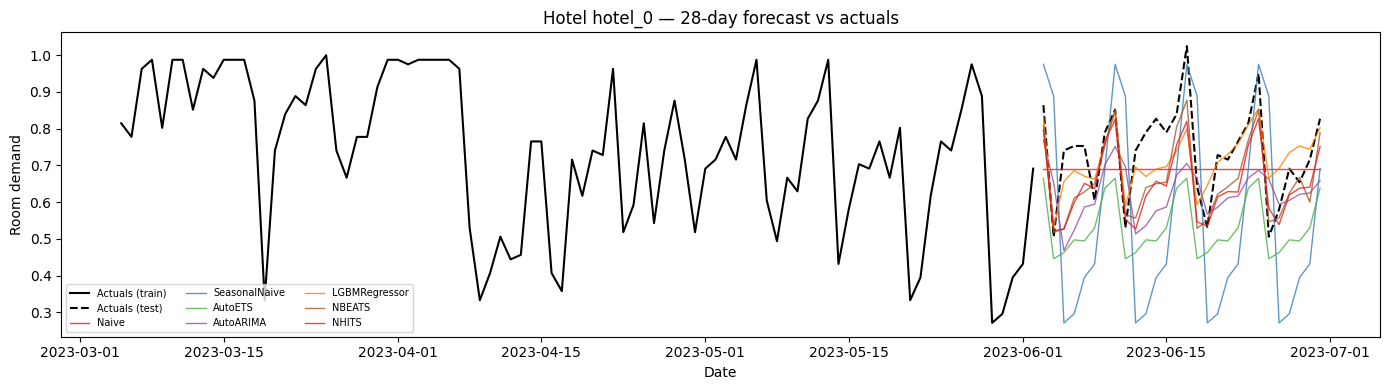

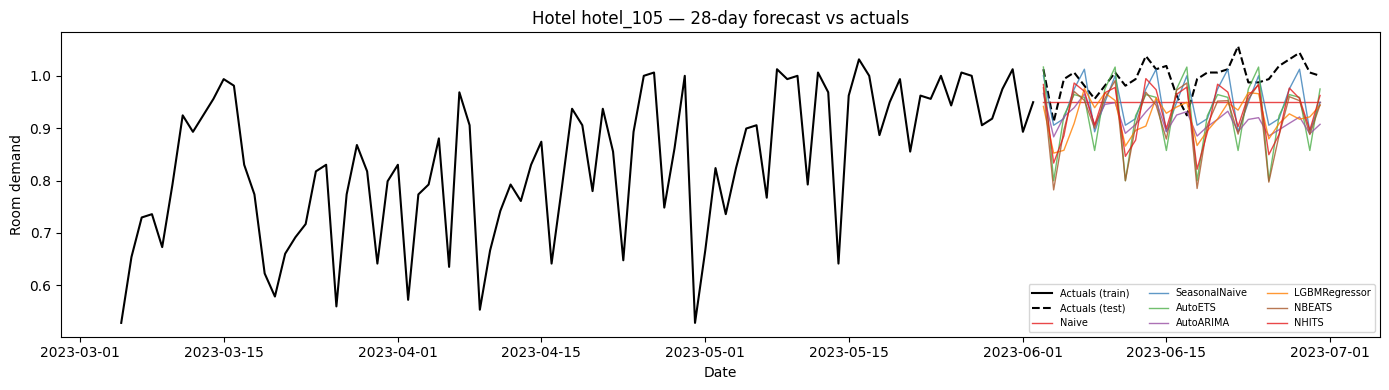

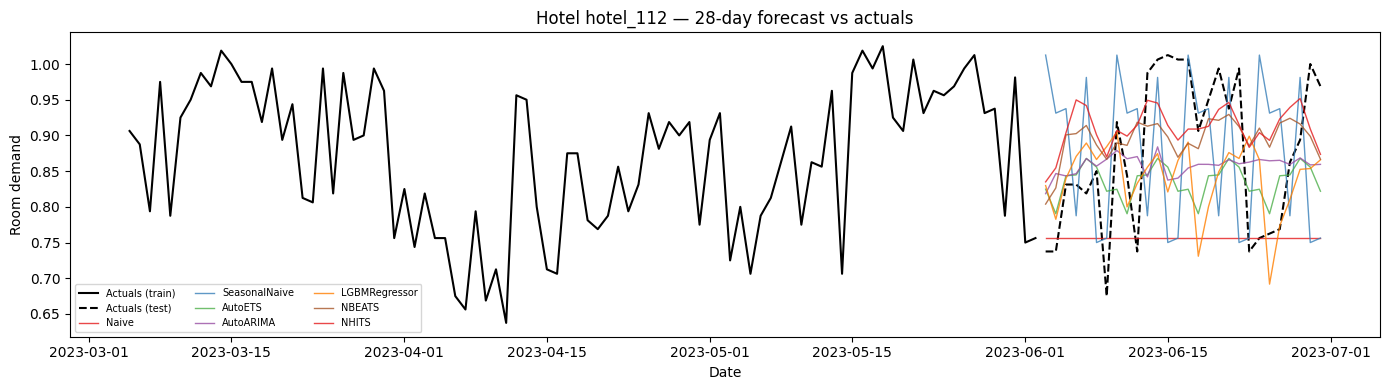

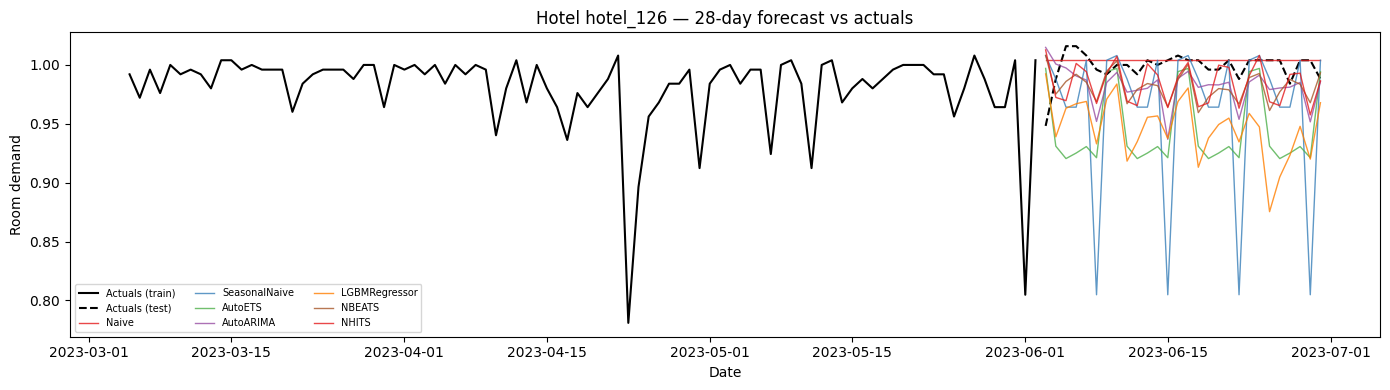

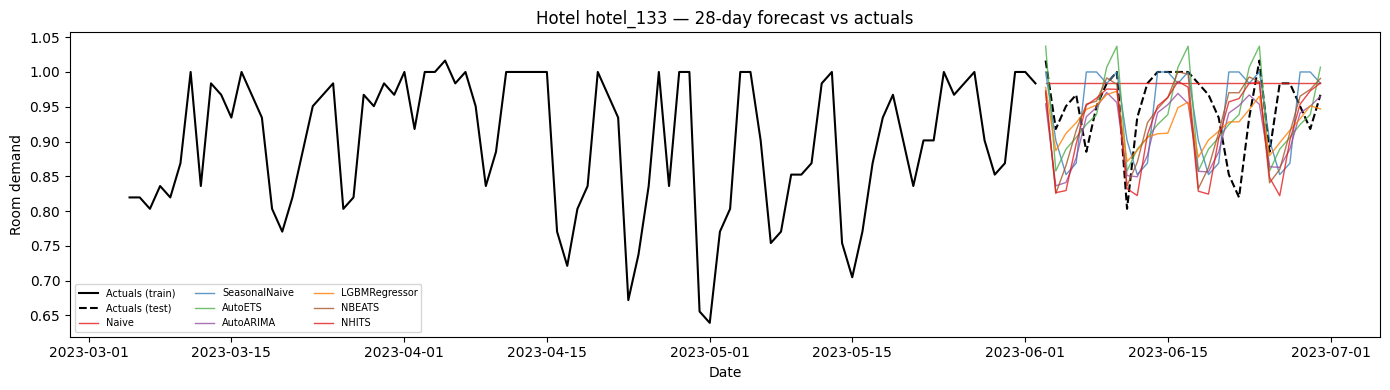

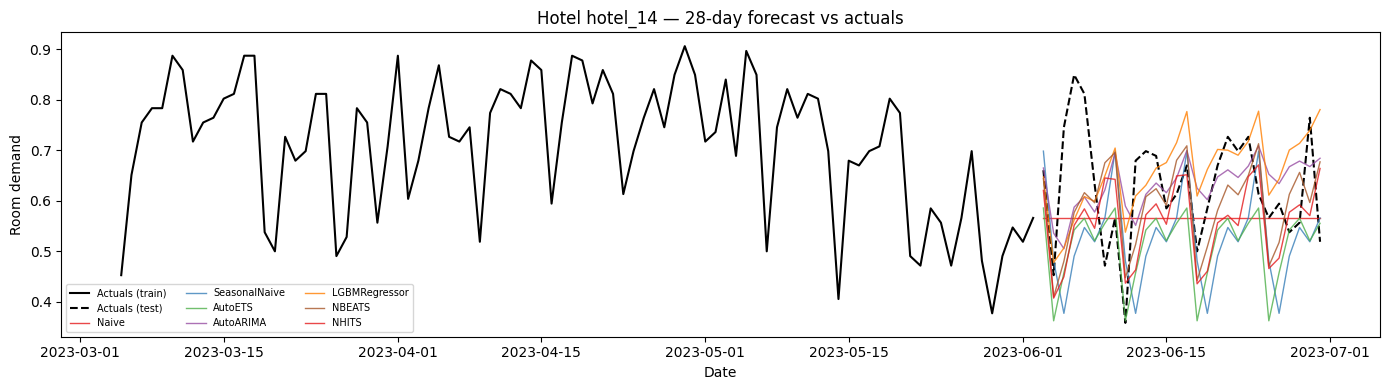

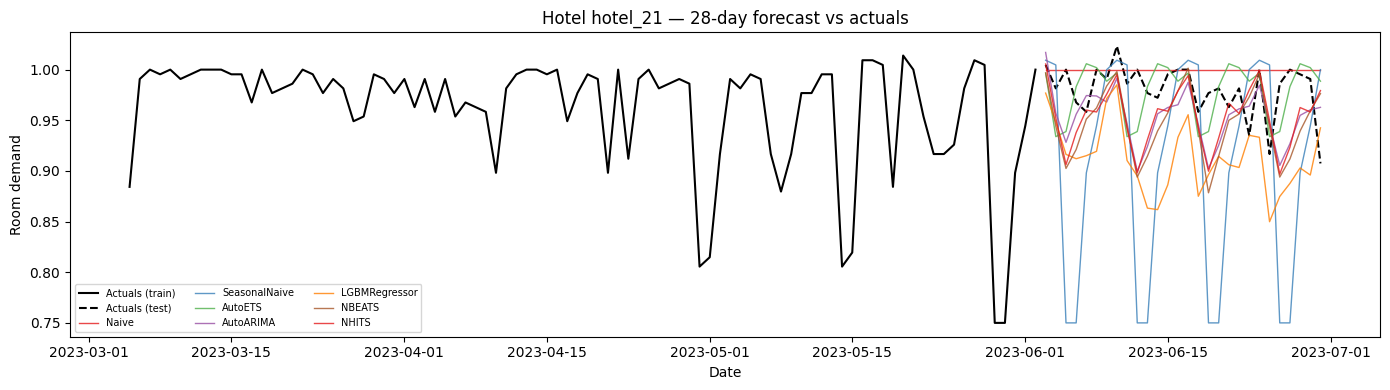

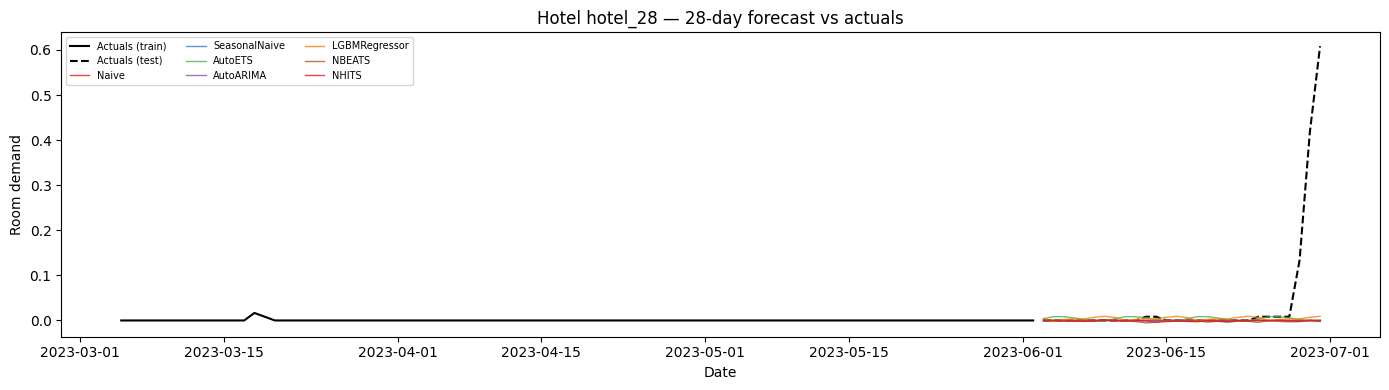

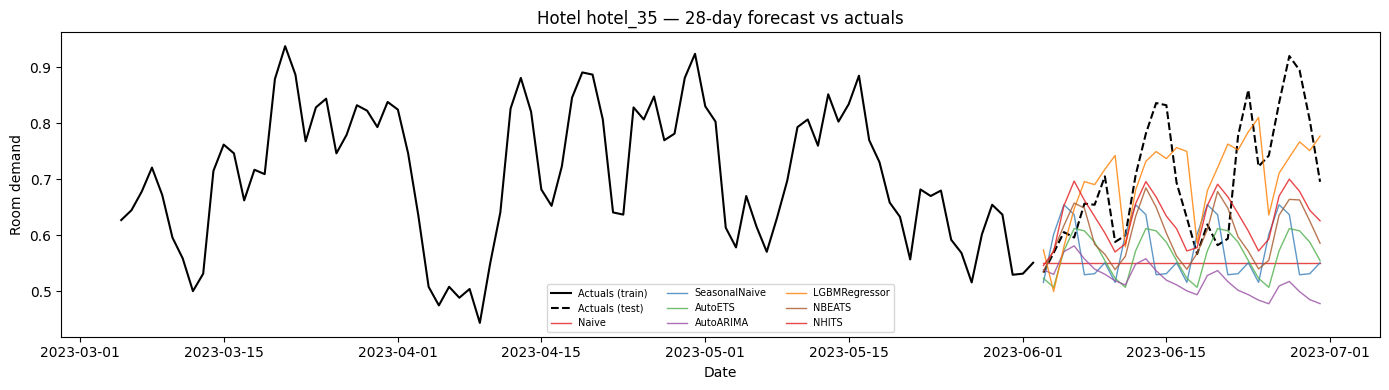

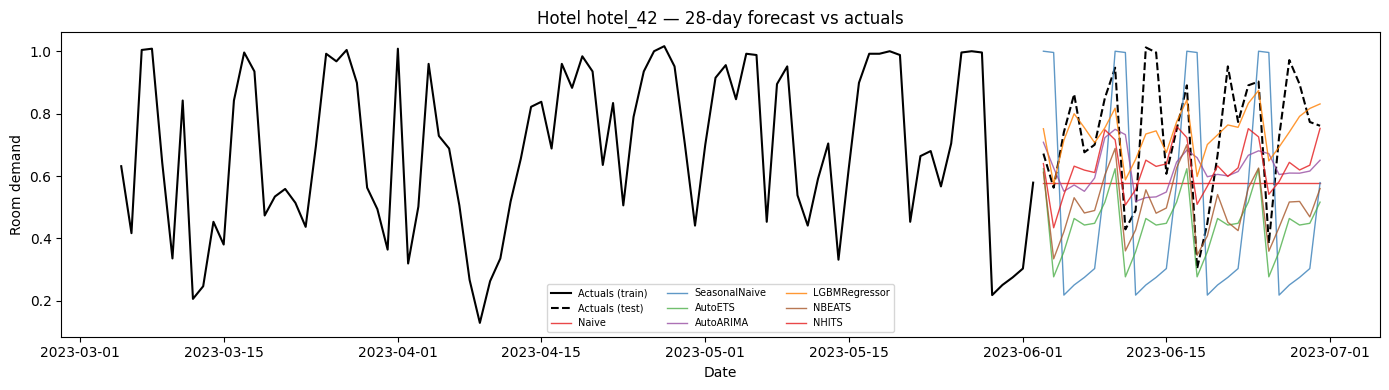

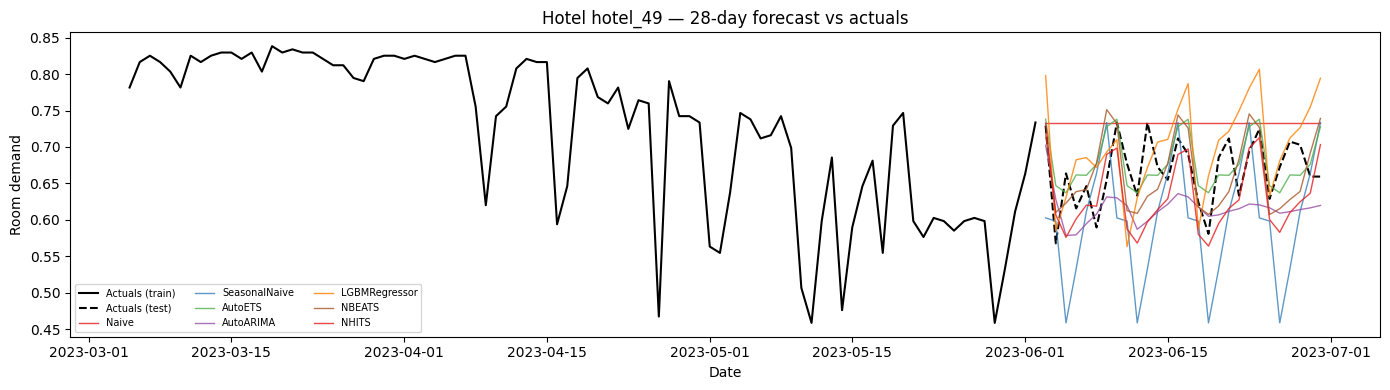

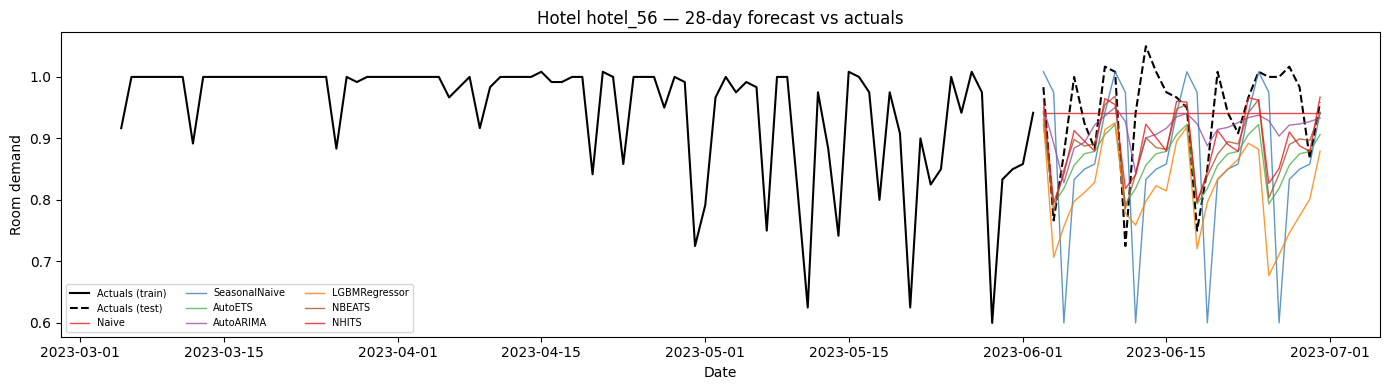

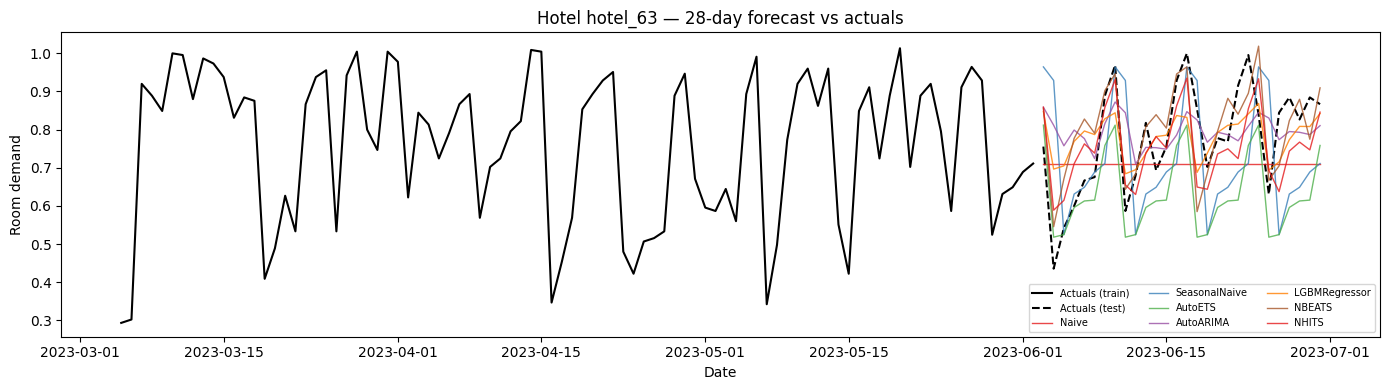

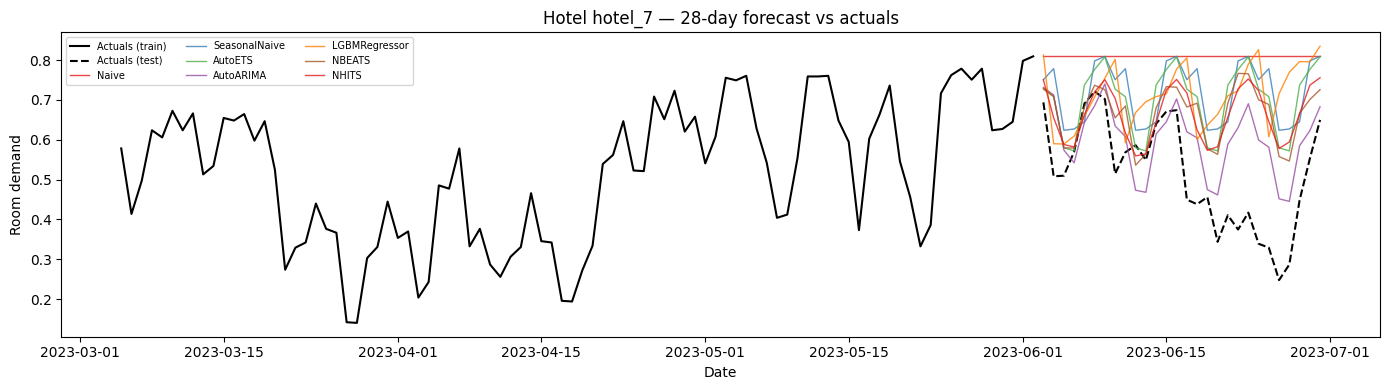

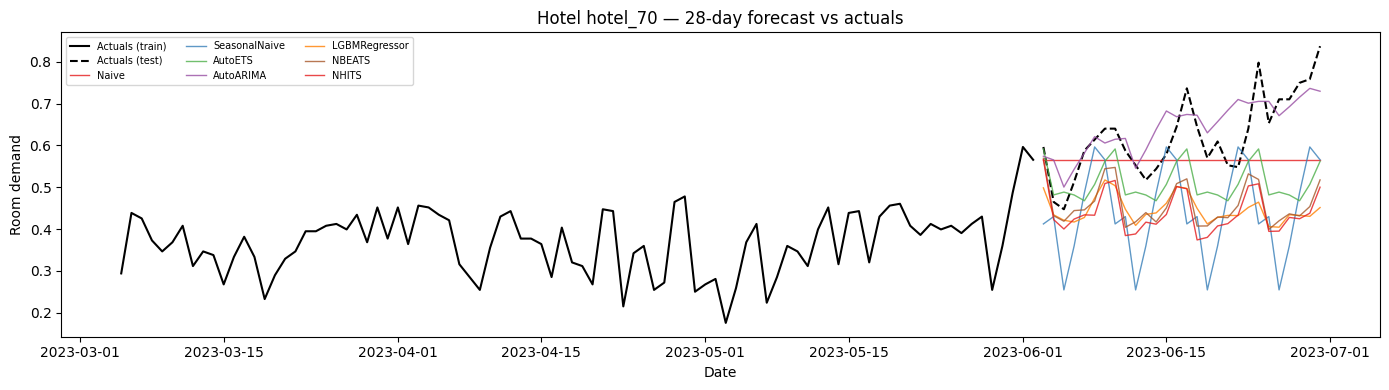

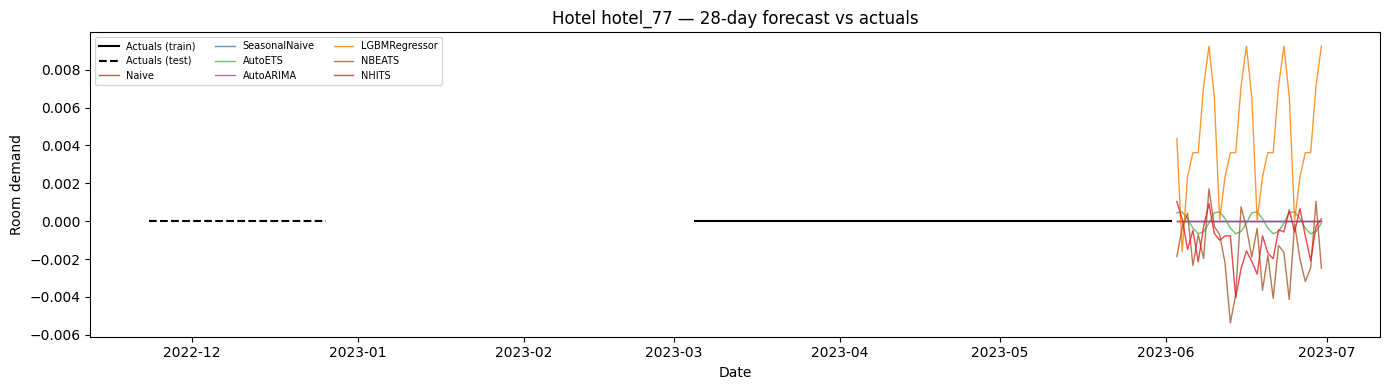

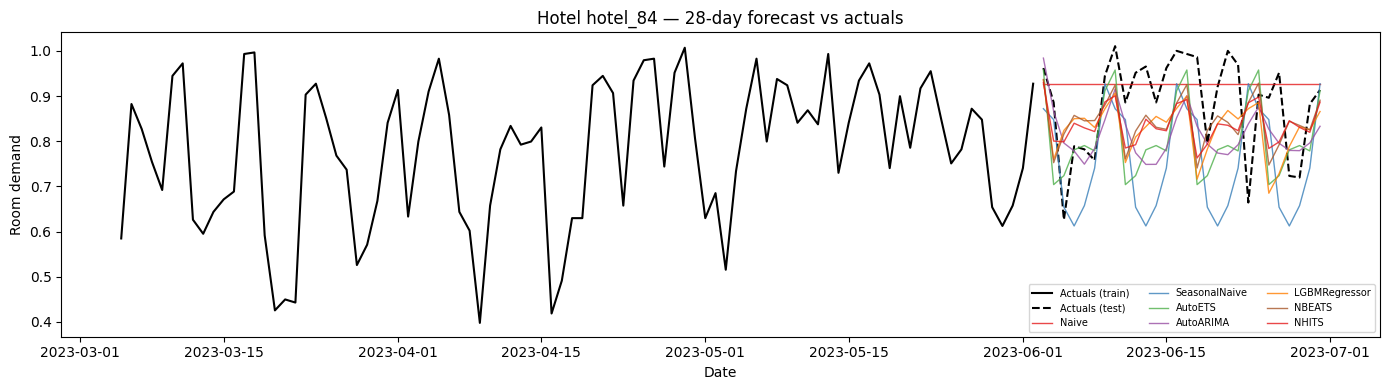

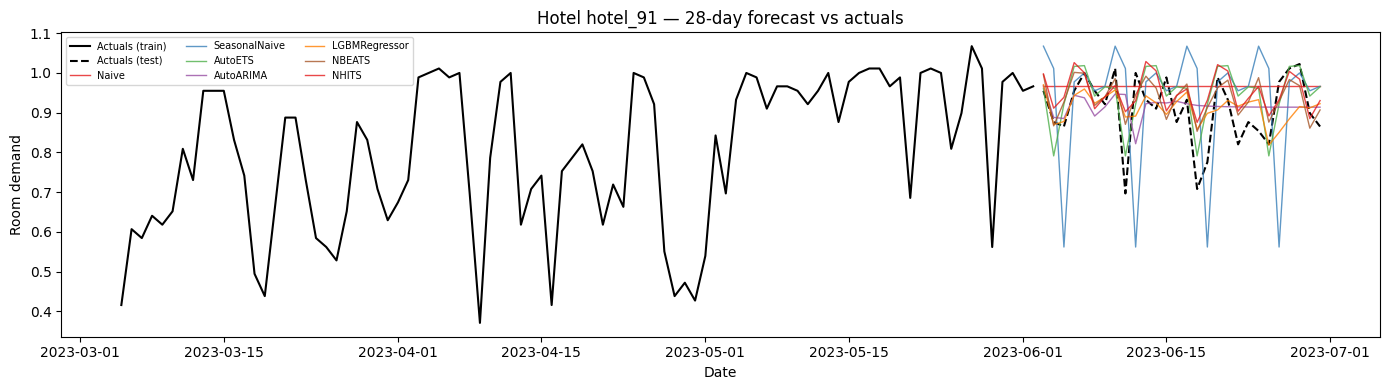

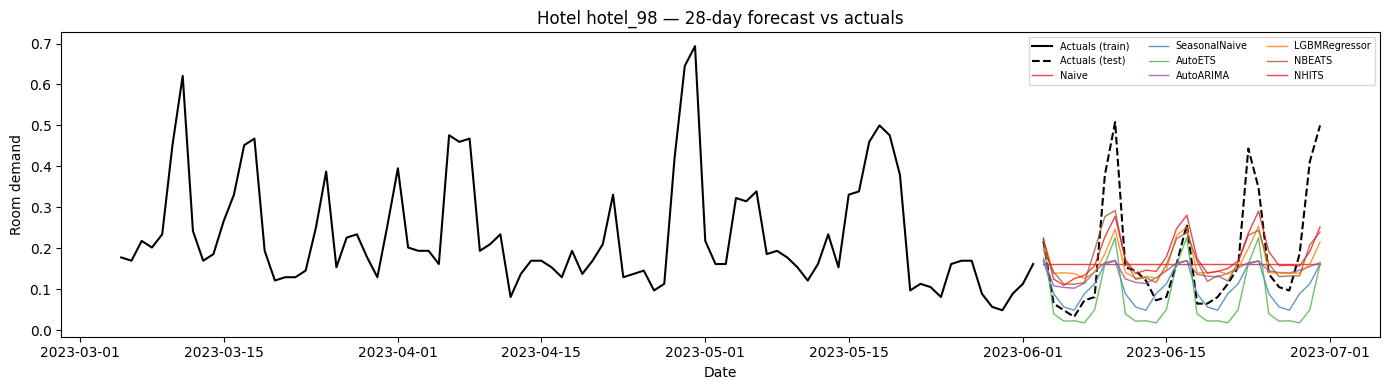

In [31]:
import matplotlib.pyplot as plt

hotel_ids = sf_train["unique_id"].unique()
model_cols_plot = [c for c in final_forecasts.columns if c not in ["unique_id", "ds"]]
colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628"]

for hotel in hotel_ids:
    actuals  = sf_train.query("unique_id == @hotel").sort_values("ds")
    test_act = sf_test.query("unique_id == @hotel").sort_values("ds")
    preds    = final_forecasts.query("unique_id == @hotel").sort_values("ds")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(actuals["ds"].iloc[-90:], actuals["y"].iloc[-90:],
            color="black", linewidth=1.5, label="Actuals (train)")
    ax.plot(test_act["ds"], test_act["y"],
            color="black", linewidth=1.5, linestyle="--", label="Actuals (test)")

    for i, col in enumerate(model_cols_plot):
        ax.plot(preds["ds"], preds[col],
                label=col, color=colors[i % len(colors)], linewidth=1, alpha=0.8)

    ax.set_title(f"Hotel {hotel} — 28-day forecast vs actuals")
    ax.set_xlabel("Date")
    ax.set_ylabel("Room demand")
    ax.legend(fontsize=7, ncol=3)
    plt.tight_layout()
    plt.savefig(f"plots/forecast_{hotel}.png", dpi=100)
    plt.show()
    plt.close()

## Cell 25 — Download all outputs

In [33]:
import shutil
from google.colab import files

shutil.make_archive("hotel-1_project_outputs", "zip", "outputs")
files.download("hotel-1_project_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>